## Phase 7: Optimization

Run linear optimal power flow (LOPF) to optimize network operation.

In [8]:
import pypsa
# Load the saved pre-optimization network
print("Loading pre-optimization network...")
network = pypsa.Network("tyndp2024_network_2030_preoptimization.nc")
print(f"  Snapshots : {len(network.snapshots)}")
print(f"  Generators: {len(network.generators)}")
print(f"  Storage   : {len(network.storage_units)}")
print(f"  Loads     : {len(network.loads)}")
print(f"  Links     : {len(network.links)}")
print()


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)


Loading pre-optimization network...


INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units


  Snapshots : 8760
  Generators: 426
  Storage   : 119
  Loads     : 52
  Links     : 209



In [9]:
import logging
logging.basicConfig(level=logging.WARNING)

print("Running network consistency check...")
network.consistency_check()
print("Done — any issues appear as warnings above.")


Running network consistency check...
Done — any issues appear as warnings above.


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x45cfd98b0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x45cf8ff50>},
 'flows': {}}

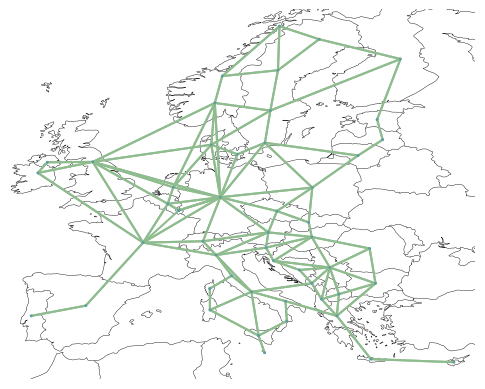

In [10]:
network.plot(geomap=True)

In [11]:
import pypsa
import pandas as pd
import time

print("Running full-year optimization (8760 hours) with Gurobi...")
start = time.time()

status, condition = network.optimize(
    solver_name="gurobi",
    io_api="direct",
    solver_options={"threads": 8},
)

elapsed = time.time() - start
print(f"Status    : {status}  |  Condition: {condition}")
print(f"Time      : {elapsed/60:.1f} min")

if status == "ok":
    print(f"Objective : €{network.objective:,.0f}")

    gen_twh  = network.generators_t.p.sum().sum() / 1e6
    load_twh = network.loads_t.p_set.sum().sum() / 1e6
    stor_twh = network.storage_units_t.p.sum().sum() / 1e6

    print(f"\nEnergy balance:")
    print(f"  Generation  : {gen_twh:,.1f} TWh")
    print(f"  Storage net : {stor_twh:,.1f} TWh")
    print(f"  Load        : {load_twh:,.1f} TWh")

    gen_mix = (
        network.generators_t.p.sum()
        .groupby(network.generators.carrier)
        .sum()
        .sort_values(ascending=False)
        / 1e6
    )
    print(f"\nGeneration mix [TWh]:")
    for carrier, twh in gen_mix.items():
        if twh > 0.01:
            print(f"  {carrier:<22}: {twh:>8.1f} TWh")

    network.export_to_netcdf("tyndp2024_network_2030_optimized_fullyear.nc")
    print(f"\nSaved → tyndp2024_network_2030_optimized_fullyear.nc")


Running full-year optimization (8760 hours) with Gurobi...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 8
INFO:linopy.model:Solver options:
 - threads: 8


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2722833


...

Solved in 0 iterations and 5.74 seconds (4.26 work units)


INFO:gurobipy:Solved in 0 iterations and 5.74 seconds (4.26 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4

Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



Status    : warning  |  Condition: infeasible_or_unbounded
Time      : 2.1 min


In [12]:
network.model.print_infeasibilities()


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G80)


INFO:gurobipy:Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G80)


INFO:gurobipy:


CPU model: Apple M1 Pro


INFO:gurobipy:CPU model: Apple M1 Pro


...

IIS computed: 49 constraints and 0 bounds


INFO:gurobipy:IIS computed: 49 constraints and 0 bounds


IIS runtime: 1.19 seconds (0.00 work units)


INFO:gurobipy:IIS runtime: 1.19 seconds (0.00 work units)


Generator-fix-p-upper[2030-01-09 17:00:00, DE00-gas-ccgt]: +1 Generator-p[2030-01-09 17:00:00, DE00-gas-ccgt] ≤ 22245.8649228
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-gas-conv]: +1 Generator-p[2030-01-09 17:00:00, DE00-gas-conv] ≤ 1054.767
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-gas-ocgt]: +1 Generator-p[2030-01-09 17:00:00, DE00-gas-ocgt] ≤ 2399.106
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-oil-light]: +1 Generator-p[2030-01-09 17:00:00, DE00-oil-light] ≤ 1585.33
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-hydro-ror-turbine]: +1 Generator-p[2030-01-09 17:00:00, DE00-hydro-ror-turbine] ≤ 1211.32092587
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-onwind]: +1 Generator-p[2030-01-09 17:00:00, DE00-onwind] ≤ 11887.8934986
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-offwind]: +1 Generator-p[2030-01-09 17:00:00, DE00-offwind] ≤ 11950.5169989
Generator-fix-p-upper[2030-01-09 17:00:00, DE00-solar-pv-utility]: +1 Generator-p[2030-01-09 17:00:00, DE00-solar-pv-uti

In [21]:
import pandas as pd

bus  = "DE00"
hour = "2030-01-09 17:00:00"

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 200)

# ── 1. All generators at DE00 — static capacity ──────────────────────────────
print(f"{'='*80}")
print(f"  GENERATORS at {bus}  —  static capacity")
print(f"{'='*80}")
gen_all = network.generators[network.generators.bus == bus][["carrier", "p_nom"]].copy()
gen_all["p_nom_GW"] = (gen_all["p_nom"] / 1000).round(3)
gen_all.index = gen_all.index.str[-35:]
print(gen_all.sort_values("p_nom", ascending=False).to_string())
print(f"\n  → Total: {network.generators[network.generators.bus == bus]['p_nom'].sum():,.0f} MW")

# ── 2. All storage units at DE00 — static capacity ───────────────────────────
print(f"\n{'='*80}")
print(f"  STORAGE UNITS at {bus}  —  static capacity")
print(f"{'='*80}")
su_all = network.storage_units[network.storage_units.bus == bus][["carrier", "p_nom", "max_hours"]].copy()
su_all["e_nom_GWh"] = (su_all["p_nom"] * su_all["max_hours"] / 1000).round(1)
su_all.index = su_all.index.str[-35:]
print(su_all.sort_values("p_nom", ascending=False).to_string())
print(f"\n  → Total p_nom: {network.storage_units[network.storage_units.bus == bus]['p_nom'].sum():,.0f} MW")

# ── 3. Generators at DE00 at critical hour (with p_max_pu and availability) ──
print(f"\n{'='*80}")
print(f"  GENERATORS at {bus}  —  {hour}")
print(f"{'='*80}")
gen = network.generators[network.generators.bus == bus].copy()

pu_row = network.generators_t.p_max_pu.loc[hour] if hour in network.generators_t.p_max_pu.index else pd.Series(dtype=float)
gen["p_max_pu"] = gen.index.map(lambda x: pu_row.get(x, 1.0))
gen["avail_MW"]  = (gen["p_nom"] * gen["p_max_pu"]).round(0)
gen["p_nom"]     = gen["p_nom"].round(0)
gen["p_max_pu"]  = gen["p_max_pu"].round(4)
out = gen[["carrier", "p_nom", "p_max_pu", "avail_MW"]].sort_values("avail_MW", ascending=False).copy()
out.index = out.index.str[-35:]
print(out.to_string())
total_gen = gen["avail_MW"].sum()
print(f"\n  → Available generation: {total_gen:,.0f} MW")

# ── 4. Storage units at DE00 at critical hour — with SoC ─────────────────────
# Real available power = min(p_nom * p_max_pu, soc * eff_dispatch)
# For pre-optimisation networks: no SoC results → fall back to state_of_charge_initial
print(f"\n{'='*80}")
print(f"  STORAGE UNITS at {bus}  —  {hour}  (real availability based on SoC)")
print(f"{'='*80}")

su_de = network.storage_units[network.storage_units.bus == bus].copy()
su_de["e_nom_MWh"] = su_de["p_nom"] * su_de["max_hours"]

# Determine SoC source: use optimisation results if available, else state_of_charge_initial
has_soc_results = (
    hasattr(network.storage_units_t, "state_of_charge")
    and len(network.storage_units_t.state_of_charge.columns) > 0
    and hour in network.storage_units_t.state_of_charge.index
)

print(f"  [SoC source: {'optimisation results' if has_soc_results else 'state_of_charge_initial (pre-optimisation)'}]\n")

print(f"  {'Unit':<35} {'p_nom':>8} {'p_max_pu':>9} {'e_nom GWh':>10} {'SoC MWh':>10} {'SoC %':>7} {'avail_MW':>10}  note")
print(f"  {'-'*100}")

total_stor_real = 0.0
total_stor_pnom = 0.0

for name, row in su_de.iterrows():
    p_nom = row["p_nom"]
    e_nom = row["e_nom_MWh"]

    # p_max_pu for storage (default = 1.0 for discharge)
    su_pu_row = network.storage_units_t.p_max_pu.loc[hour] \
        if (hasattr(network.storage_units_t, "p_max_pu") and
            len(network.storage_units_t.p_max_pu.columns) > 0 and
            hour in network.storage_units_t.p_max_pu.index) \
        else pd.Series(dtype=float)
    p_max_pu = su_pu_row.get(name, row.get("p_max_pu", 1.0))

    # SoC at the given hour
    if has_soc_results and name in network.storage_units_t.state_of_charge.columns:
        soc_mwh = network.storage_units_t.state_of_charge.loc[hour, name]
        soc_src = "opt"
    else:
        soc_mwh = row["state_of_charge_initial"]   # MWh before first snapshot
        soc_src = "init"

    soc_pct = (soc_mwh / e_nom * 100) if e_nom > 0 else 0.0

    # Dispatch constraint 1: power limit
    p_power_limit = p_nom * p_max_pu
    # Dispatch constraint 2: energy limit (how much energy is stored / Δt = 1 h)
    eff_dispatch = row.get("efficiency_dispatch", 1.0)
    p_energy_limit = soc_mwh * eff_dispatch

    avail = min(p_power_limit, p_energy_limit)

    note = ""
    if p_energy_limit < p_power_limit * 0.5:
        note = f"⚠️  energy-limited! (SoC={soc_mwh:.0f} MWh << e_nom={e_nom:.0f} MWh)"
    elif soc_src == "init" and soc_mwh == 0:
        note = "⚠️  SoC_initial=0 → no stored energy (worst case)"

    short_name = name[-35:]
    print(f"  {short_name:<35} {p_nom:>8.0f} {p_max_pu:>9.3f} {e_nom/1000:>10.1f} {soc_mwh:>10.1f} {soc_pct:>7.1f}% {avail:>10.0f}  {note}")
    total_stor_real += avail
    total_stor_pnom += p_nom

print(f"\n  → Storage available (p_nom, upper limit) : {total_stor_pnom:>10,.0f} MW")
print(f"  → Storage available (real, based on SoC) : {total_stor_real:>10,.0f} MW")
if total_stor_real < total_stor_pnom:
    print(f"  ⚠️  Difference: {total_stor_pnom - total_stor_real:,.0f} MW unavailable due to low SoC!")

# ── 5. Import links ──────────────────────────────────────────────────────────
lnk_in = network.links[network.links.bus1 == bus].copy()
lnk_in["avail_MW"] = (lnk_in["p_nom"] * lnk_in["efficiency"]).round(0)
total_import = lnk_in["avail_MW"].sum()
print(f"\n{'='*80}")
print(f"  IMPORT LINKS into {bus}")
print(f"{'='*80}")
print(lnk_in[["bus0", "p_nom", "efficiency", "avail_MW"]].sort_values("avail_MW", ascending=False).to_string())
print(f"\n  → Total import: {total_import:,.0f} MW")

# ── 6. Summary ───────────────────────────────────────────────────────────────
load_idx = network.loads[network.loads.bus == bus].index[0]
load_val = network.loads_t.p_set.loc[hour, load_idx]

total_supply_pnom = total_gen + total_stor_pnom + total_import
total_supply_real = total_gen + total_stor_real + total_import
shortfall_pnom = load_val - total_supply_pnom
shortfall_real = load_val - total_supply_real

print(f"\n{'='*80}")
print(f"  Generators (avail)         : {total_gen:>10,.0f} MW")
print(f"  Storage (p_nom, upper lim) : {total_stor_pnom:>10,.0f} MW")
print(f"  Storage (real, SoC-based)  : {total_stor_real:>10,.0f} MW")
print(f"  Import                     : {total_import:>10,.0f} MW")
print(f"  ─────────────────────────────────────────")
print(f"  MAX SUPPLY (p_nom)         : {total_supply_pnom:>10,.0f} MW")
print(f"  MAX SUPPLY (real SoC)      : {total_supply_real:>10,.0f} MW")
print(f"  DEMAND                     : {load_val:>10,.0f} MW")
print(f"  SHORTFALL (p_nom)          : {shortfall_pnom:>10,.0f} MW  {'❌ INFEASIBLE' if shortfall_pnom > 0 else '✓ OK'}")
print(f"  SHORTFALL (real SoC)       : {shortfall_real:>10,.0f} MW  {'❌ INFEASIBLE' if shortfall_real > 0 else '✓ OK'}")


  GENERÁTORY na DE00  —  statická kapacita
                                              carrier          p_nom  p_nom_GW
name                                                                          
DE00-solar-pv-rooftop                solar-pv-rooftop  118000.000000   118.000
DE00-onwind                                    onwind  115000.700000   115.001
DE00-solar-pv-utility                solar-pv-utility   97002.000000    97.002
DE00-offwind                                  offwind   30521.300000    30.521
DE00-gas-ccgt                                     gas   22245.864923    22.246
DE00-other-res                              other-res   13067.586000    13.068
DE00-h2-ccgt                                  h2-ccgt    8826.166000     8.826
s-conventional-old-1-other-128.4eur     other-thermal    7280.020000     7.280
DE00-hydro-ror-turbine                      hydro-ror    3933.900000     3.934
DE00-gas-ocgt                                     gas    2399.106000     2.399
DE00-oil-

In [17]:

import pandas as pd

bus  = "DE00"
hour = "2030-01-09 17:00:00"

print(f"=== EXACT BALANCE  {bus}  @  {hour} ===\n")

# ── Generators ──────────────────────────────────────────────────────────────
gen = network.generators[network.generators.bus == bus].copy()
pu_row = (
    network.generators_t.p_max_pu.reindex(columns=gen.index).loc[hour]
    if hour in network.generators_t.p_max_pu.index
    else pd.Series(dtype=float)
)
gen["pu"]    = gen.index.map(lambda x: pu_row.get(x, 1.0))
gen["avail"] = gen.p_nom * gen["pu"]

print(f"{'Generator':<50} {'p_nom':>9} {'p_max_pu':>9} {'avail MW':>9}")
print("-" * 80)
for name, row in gen.sort_values("avail", ascending=False).iterrows():
    print(f"  {name:<48} {row.p_nom:>9.0f} {row.pu:>9.3f} {row.avail:>9.0f}")
total_gen = gen["avail"].sum()
print(f"\n  → Generators total: {total_gen:,.0f} MW")

# ── Storage ──────────────────────────────────────────────────────────────────
su = network.storage_units[network.storage_units.bus == bus]
total_stor = su.p_nom.sum()
print(f"\n  Storage (max dispatch, p_nom): {total_stor:,.0f} MW")
for name, row in su.iterrows():
    print(f"    {name:<46} {row.p_nom:>9.0f} MW")

# ── Imports ───────────────────────────────────────────────────────────────────
lnk_in = network.links[network.links.bus1 == bus]
total_import = (lnk_in.p_nom * lnk_in.efficiency).sum()
print(f"\n  Import links (after efficiency):")
for name, row in lnk_in.sort_values("p_nom", ascending=False).iterrows():
    print(f"    {name:<46} {row.p_nom * row.efficiency:>9.0f} MW")
print(f"  → Import total: {total_import:,.0f} MW")

# ── Load ─────────────────────────────────────────────────────────────────────
load_idx = network.loads[network.loads.bus == bus].index[0]
load_val = network.loads_t.p_set.loc[hour, load_idx]

# ── Summary ───────────────────────────────────────────────────────────────────
total_supply = total_gen + total_stor + total_import
shortfall    = load_val - total_supply

print(f"\n{'='*60}")
print(f"  Generators : {total_gen:>10,.0f} MW")
print(f"  Storage    : {total_stor:>10,.0f} MW")
print(f"  Import     : {total_import:>10,.0f} MW")
print(f"  {'─'*30}")
print(f"  MAX SUPPLY : {total_supply:>10,.0f} MW")
print(f"  DEMAND     : {load_val:>10,.0f} MW")
print(f"  SHORTFALL  : {shortfall:>10,.0f} MW  {'❌ INFEASIBLE' if shortfall > 0 else '✓ OK'}")

# ── Missing resources analysis ────────────────────────────────────────────────
print(f"\n=== MISSING RESOURCES ANALYSIS ===")
print(f"\nExpected in TYNDP 2024 DE00 2030 (not in model):")
print(f"  DSR (Demand Side Response):  ~44,500 MW  ← missing as a generator carrier")
print(f"  Nuclear:                       ~8,000 MW  ← checking...")
nuclear = gen[gen.carrier == "nuclear"]
uranium = gen[gen.carrier == "uranium"]
print(f"  Nuclear in model (carrier=nuclear): {nuclear.p_nom.sum():>9,.0f} MW")
print(f"  Nuclear in model (carrier=uranium): {uranium.p_nom.sum():>9,.0f} MW")


=== PRESNÁ BILANCIA DE00 @ 2030-01-09 17:00:00 ===

Generátor                                              p_nom  p_max_pu     avail
--------------------------------------------------------------------------------
  DE00-offwind                                         30521     0.392     11951
  DE00-onwind                                         115001     0.103     11888
  DE00-hydro-ror-turbine                                3934     0.308      1211
  DE00-solar-pv-utility                                97002     0.000         0
  DE00-solar-pv-rooftop                               118000     0.000         0
  DE00-gas-ccgt                                        22246       nan       nan
  DE00-gas-conv                                         1055       nan       nan
  DE00-gas-ocgt                                         2399       nan       nan
  DE00-oil-light                                        1585       nan       nan
  DE00-h2-ccgt                                          8

In [14]:
hour = "2030-01-09 17:00:00"
bus  = "DE00"

print(f"=== BALANCE  {bus}  —  {hour} ===\n")

gen = network.generators[network.generators.bus == bus].copy()
pu  = network.generators_t.p_max_pu.loc[hour]
gen["p_max_pu"]    = gen.index.map(lambda x: pu.get(x, 1.0))
gen["p_available"] = gen.p_nom * gen["p_max_pu"]

print("GENERATORS (available MW):")
print(
    gen[["carrier", "p_nom", "p_max_pu", "p_available"]]
    .round(1)
    .sort_values("p_available", ascending=False)
    .head(15)
)

total_gen  = gen["p_available"].sum()
stor_max   = network.storage_units[network.storage_units.bus == bus].p_nom.sum()
imports    = (
    network.links[network.links.bus1 == bus].p_nom
    * network.links[network.links.bus1 == bus].efficiency
).sum()
load = network.loads_t.p_set.loc[
    hour, network.loads[network.loads.bus == bus].index[0]
]

print(f"\nLocal generation total : {total_gen:,.0f} MW")
print(f"Storage max dispatch   : {stor_max:,.0f} MW")
print(f"Max import             : {imports:,.0f} MW")
print(f"Demand                 : {load:,.0f} MW")
print(f"Shortfall              : {load - (total_gen + stor_max + imports):,.0f} MW  "
      f"{'❌ INFEASIBLE' if load - (total_gen + stor_max + imports) > 0 else '✓ OK'}")


=== BILANCIA DE00 — 2030-01-09 17:00:00 ===

GENERÁTORY (dostupné MW):
                                                         carrier     p_nom  \
name                                                                         
DE00-gas-ccgt                                                gas   22245.9   
DE00-other-res                                         other-res   13067.6   
DE00-offwind                                             offwind   30521.3   
DE00-onwind                                               onwind  115000.7   
DE00-h2-ccgt                                             h2-ccgt    8826.2   
DE00-chp-gas-conventional-old-1-other-128.4eur     other-thermal    7280.0   
DE00-gas-ocgt                                                gas    2399.1   
DE00-oil-light                                         oil-light    1585.3   
DE00-hydro-ror-turbine                                 hydro-ror    3933.9   
DE00-gas-conv                                                gas    105

In [18]:
hour = "2030-01-09 17:00:00"
bus  = "DE00"

print(f"=== DETAILED BALANCE  {bus}  —  {hour} ===\n")

# ── 1. Generators with actual p_max_pu applied ───────────────────────────────
gen = network.generators[network.generators.bus == bus].copy()
pu_row = network.generators_t.p_max_pu.loc[hour] if hour in network.generators_t.p_max_pu.index else pd.Series(dtype=float)
gen["p_max_pu"]    = gen.index.map(lambda x: pu_row.get(x, 1.0))
gen["p_available"] = gen.p_nom * gen["p_max_pu"]

print(f"{'GENERATOR':<45} {'p_nom':>8} {'p_max_pu':>9} {'avail MW':>9}")
print("-" * 76)
for idx, row in gen.sort_values("p_available", ascending=False).iterrows():
    print(f"  {idx:<43} {row.p_nom:>8.0f} {row['p_max_pu']:>9.3f} {row.p_available:>9.0f}")
total_gen = gen["p_available"].sum()
print(f"\n  → Generators total: {total_gen:,.0f} MW")

# ── 2. Storage units ─────────────────────────────────────────────────────────
print(f"\n{'STORAGE':<45} {'p_nom':>8}  {'inflow':>8}  {'note'}")
print("-" * 76)
su_de = network.storage_units[network.storage_units.bus == bus]
total_stor = 0.0
for name, row in su_de.iterrows():
    inflow = network.storage_units_t.inflow[name].loc[hour] if name in network.storage_units_t.inflow.columns else 0.0
    note = ""
    if inflow > row.p_nom:
        note = f"⚠️  inflow {inflow:.0f} > p_nom {row.p_nom:.0f}"
    print(f"  {name:<43} {row.p_nom:>8.0f}  {inflow:>8.1f}  {note}")
    total_stor += row.p_nom
print(f"\n  → Storage total (max dispatch): {total_stor:,.0f} MW")

# ── 3. Import links ──────────────────────────────────────────────────────────
print(f"\n{'IMPORT LINK':<35} {'p_nom':>8} {'eff':>6} {'after eff':>10}")
print("-" * 64)
lnk_in = network.links[network.links.bus1 == bus]
total_import = 0.0
for name, row in lnk_in.iterrows():
    after = row.p_nom * row.efficiency
    print(f"  {name:<33} {row.p_nom:>8.0f} {row.efficiency:>6.3f} {after:>10.0f}")
    total_import += after
print(f"\n  → Import total (after efficiency): {total_import:,.0f} MW")

# ── 4. Load ──────────────────────────────────────────────────────────────────
load_idx = network.loads[network.loads.bus == bus].index[0]
load_val = network.loads_t.p_set.loc[hour, load_idx]
print(f"\n  Demand (load): {load_val:,.0f} MW")

# ── 5. Summary ───────────────────────────────────────────────────────────────
total_supply = total_gen + total_stor + total_import
shortfall    = load_val - total_supply
print(f"\n{'─'*50}")
print(f"  Generators   : {total_gen:>10,.0f} MW")
print(f"  Storage      : {total_stor:>10,.0f} MW")
print(f"  Import (×eff): {total_import:>10,.0f} MW")
print(f"  {'─'*29}")
print(f"  MAX SUPPLY   : {total_supply:>10,.0f} MW")
print(f"  DEMAND       : {load_val:>10,.0f} MW")
print(f"  SHORTFALL    : {shortfall:>10,.0f} MW  {'❌ INFEASIBLE' if shortfall > 0 else '✓ OK'}")


=== DETAILNÁ BILANCIA DE00 — 2030-01-09 17:00:00 ===

GENERATOR                                        p_nom  p_max_pu  avail MW
----------------------------------------------------------------------------
  DE00-gas-ccgt                                  22246     1.000     22246
  DE00-other-res                                 13068     1.000     13068
  DE00-offwind                                   30521     0.392     11951
  DE00-onwind                                   115001     0.103     11888
  DE00-h2-ccgt                                    8826     1.000      8826
  DE00-chp-gas-conventional-old-1-other-128.4eur     7280     1.000      7280
  DE00-gas-ocgt                                   2399     1.000      2399
  DE00-oil-light                                  1585     1.000      1585
  DE00-hydro-ror-turbine                          3934     0.308      1211
  DE00-gas-conv                                   1055     1.000      1055
  DE00-solar-pv-utility                  

In [2]:

import pandas as pd

print("=" * 65)
print("HYDRO INFLOW DIAGNOSTICS")
print("=" * 65)

su   = network.storage_units
su_t = network.storage_units_t

# 1. Peak inflow > p_nom → solver cannot dispatch fast enough → infeasible
print("\n1. Peak inflow > p_nom  (solver cannot dispatch fast enough)")
print(f"   {'Unit':<45} {'p_nom':>8} {'peak_inflow':>12} {'ratio':>7}")
print(f"   {'-'*75}")
found = False
for name in su.index:
    if name not in su_t.inflow.columns:
        continue
    p_nom = su.loc[name, "p_nom"]
    peak  = su_t.inflow[name].max()
    if peak > p_nom * 1.001:
        print(f"   ⚠️  {name:<45} {p_nom:>8.0f} {peak:>12.0f} {peak/p_nom:>7.2f}x")
        found = True
if not found:
    print("   OK — all peak inflows ≤ p_nom")

# 2. Annual inflow > e_nom → reservoir overflows → infeasible with cyclic SoC
print("\n2. Annual inflow > e_nom  (reservoir overflow with cyclic SoC)")
print(f"   {'Unit':<45} {'e_nom MWh':>10} {'annual MWh':>12} {'ratio':>7}")
print(f"   {'-'*75}")
found = False
for name in su.index:
    if name not in su_t.inflow.columns:
        continue
    p_nom     = su.loc[name, "p_nom"]
    max_hours = su.loc[name, "max_hours"]
    e_nom     = p_nom * max_hours
    annual    = su_t.inflow[name].sum()
    if e_nom > 0 and annual > e_nom * 1.1:
        ratio = annual / e_nom
        print(f"   ⚠️  {name:<45} {e_nom:>10.0f} {annual:>12.0f} {ratio:>7.1f}x")
        found = True
if not found:
    print("   OK — no overflow issues")

# 3. DE00 shortfall analysis — finding missing capacity
print("\n3. DE00 shortfall analysis — finding missing capacity")
bus  = "DE00"
hour = "2030-01-02 16:00:00"

# All storage units at DE00
de_stor = su[su.bus == bus]
print(f"\n   Storage units at {bus}:")
print(de_stor[["carrier", "p_nom", "max_hours", "cyclic_state_of_charge"]].to_string())

# Inflow at DE00 at the critical hour
print(f"\n   Inflow at {hour}:")
for name in de_stor.index:
    if name in su_t.inflow.columns:
        val = su_t.inflow.loc[hour, name]
        print(f"     {name}: inflow = {val:.1f} MW  (p_nom = {de_stor.loc[name, 'p_nom']:.0f} MW)")

# Check links at DE00 — bi-directional?
print(f"\n   Links to/from {bus}:")
lnk_in  = network.links[network.links.bus1 == bus][["bus0", "p_nom", "efficiency"]]
lnk_out = network.links[network.links.bus0 == bus][["bus1", "p_nom", "efficiency"]]
print("   Import (bus1=DE00):")
print(lnk_in.to_string())
print("   Export (bus0=DE00):")
print(lnk_out.to_string())


HYDRO INFLOW DIAGNOSTICS


NameError: name 'network' is not defined

In [ ]:
# # Testujeme len 3 hodiny okolo problému
# critical = pd.date_range("2030-01-09 15:00", "2030-01-09 17:00", freq="H")
# network.snapshots = critical

# print("Testujem LOPF len na kritické hodiny...")
# status, condition = network.lopf(
#     solver_name="highs",
#     pyomo=False,
#     solver_options={"log_to_console": True}
# )
# print(status, condition)

Testujem LOPF len na kritické hodiny...


/var/folders/kr/02s80h4x0pn0rxjq93w2tjz00000gn/T/ipykernel_69887/3984491520.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



AttributeError: 'Network' object has no attribute 'lopf'

In [ ]:
# print("Availability (p_max_pu) BE00 termálne zdroje v januári:")
# thermal = network.generators[
#     (network.generators.bus == "BE00") & 
#     ~network.generators.carrier.isin(["onwind","offwind","solar-pv-rooftop","hydro-ror"])
# ]
# print(network.generators_t.p_max_pu.loc["2030-01-01":"2030-01-31", thermal.index].describe())

In [ ]:
# hour = "2030-01-09 16:00:00"
# bus = "BE00"

# print(f"=== DETAILNÁ BILANCIA {bus} — {hour} ===")

# # Generátory
# gen = network.generators[network.generators.bus == bus].copy()
# avail = network.generators_t.p_max_pu.loc[hour] if hour in network.generators_t.p_max_pu.index else pd.Series()
# gen['pu'] = gen.index.map(lambda x: avail.get(x, 1.0))
# gen['p_available'] = gen.p_nom * gen['pu']
# local_gen = gen['p_available'].sum()

# print(f"  Lokálna generácia (po deratingu): {local_gen:,.0f} MW")
# for idx, row in gen.sort_values('p_available', ascending=False).iterrows():
#     print(f"     {idx:35} {row['p_available']:6.0f} MW  (p_nom {row.p_nom:5.0f} × {row.pu:.3f})")

# # Storage (max discharge)
# stor_max = network.storage_units[network.storage_units.bus == bus].p_nom.sum()
# print(f"  Storage max discharge: {stor_max:,.0f} MW")

# # Importy
# imports = network.links[network.links.bus1 == bus]
# max_import = (imports.p_nom * imports.efficiency).sum()
# print(f"  Max import (po efficiency): {max_import:,.0f} MW")

# total_max = local_gen + stor_max + max_import
# print(f"\n  → CELKOVÁ MAX DODÁVKA: {total_max:,.0f} MW")

# # Správna detekcia loadu (opravene)
# load_mask = network.loads.bus == bus
# if load_mask.any():
#     load_name = network.loads[load_mask].index[0]          # vezme prvý (zvyčajne jediný)
#     load = network.loads_t.p_set.loc[hour, load_name]
#     print(f"  Spotreba (load): {load:,.0f} MW")
#     print(f"  → SHORTFALL: {load - total_max:,.0f} MW")
# else:
#     print("  Žiadna load pre tento bus")

=== DETAILNÁ BILANCIA BE00 — 2030-01-09 16:00:00 ===
  Lokálna generácia (po deratingu): 6,325 MW
     BE00-gas-ccgt                         2224 MW  (p_nom  3507 × 0.634)
     BE00-nuclear                          1317 MW  (p_nom  2077 × 0.634)
     BE00-chp-gas-conventional-old-2-industrial-0eur   1011 MW  (p_nom  1594 × 0.634)
     BE00-other-res                         615 MW  (p_nom   615 × 1.000)
     BE00-gas-conv                          552 MW  (p_nom   871 × 0.634)
     BE00-coal                              225 MW  (p_nom   354 × 0.634)
     BE00-gas-ocgt                          155 MW  (p_nom   244 × 0.634)
     BE00-oil-heavy                          89 MW  (p_nom   140 × 0.634)
     BE00-onwind                             84 MW  (p_nom  5248 × 0.016)
     BE00-hydro-ror-turbine                  43 MW  (p_nom   148 × 0.288)
     BE00-offwind                            11 MW  (p_nom  4360 × 0.002)
     BE00-solar-pv-rooftop                    0 MW  (p_nom 13610 × 0.000)
  

In [ ]:
# import pandas as pd
# import numpy as np

# print("=" * 60)
# print("NETWORK SANITY FIXES (safety net before optimization)")
# print("=" * 60)

# # FIX 1: Clip any negative p_max_pu to 0
# print("\nFIX 1: Clip negative p_max_pu → 0")
# clipped_neg = 0
# for col in network.generators_t.p_max_pu.columns:
#     ts = network.generators_t.p_max_pu[col]
#     if (ts < 0).any():
#         network.generators_t.p_max_pu[col] = ts.clip(lower=0.0)
#         clipped_neg += 1
# print(f"  → {clipped_neg} generator profiles clipped")

# # FIX 2: Clip inflow to p_nom
# # Peak inflow > p_nom forces dispatch above capacity → infeasible
# print("\nFIX 2: Clip inflow to p_nom (17 hydro units majú peak inflow > p_nom)")
# clipped_inflow = 0
# for su_name in network.storage_units.index:
#     if su_name in network.storage_units_t.inflow.columns:
#         p_nom = network.storage_units.loc[su_name, 'p_nom']
#         ts = network.storage_units_t.inflow[su_name]
#         if (ts > p_nom).any():
#             network.storage_units_t.inflow[su_name] = ts.clip(upper=p_nom)
#             clipped_inflow += 1
#             print(f"  Clipped: {su_name}  (peak was {ts.max():.0f} MW, p_nom={p_nom:.0f} MW)")
# print(f"  → {clipped_inflow} inflow series clipped")

# # FIX 3: Remove links with p_nom=0
# print("\nFIX 3: Remove zero p_nom links")
# zero_links = network.links[network.links.p_nom <= 0].index.tolist()
# if zero_links:
#     print(f"  Removing: {zero_links}")
#     network.remove("Link", zero_links)
#     print(f"  → {len(zero_links)} links removed")
# else:
#     print("  None found — OK")

# print("\n✓ Všetky fixy aplikované")


In [7]:
# import pypsa
# import pandas as pd
# import numpy as np

# print("=" * 60)
# print("INFEASIBILITY DIAGNOSTICS")
# print("=" * 60)

# n = pypsa.Network("tyndp2024_network_2030_preoptimization.nc")

# # ── 1. p_min_pu on generators (must-run forcing excess generation) ──
# print("\n1. Generators with p_min_pu > 0 (must-run)")
# gen_min = n.generators[n.generators['p_min_pu'] > 0][['bus', 'carrier', 'p_nom', 'p_min_pu']]
# if len(gen_min):
#     print(f"   {len(gen_min)} generators with p_min_pu > 0:")
#     print(gen_min.to_string())
# else:
#     print("   None — OK")

# # ── 2. Dynamic p_min_pu in generators_t ──
# if 'p_min_pu' in n.generators_t and len(n.generators_t.p_min_pu.columns):
#     dyn_min = n.generators_t.p_min_pu
#     problematic = dyn_min.columns[(dyn_min > 0).any()]
#     print(f"\n2. Dynamic p_min_pu > 0: {len(problematic)} generators")
#     if len(problematic):
#         print("   ", list(problematic[:10]))
# else:
#     print("\n2. No dynamic p_min_pu — OK")

# # ── 3. Minimum generation vs peak load per bus ──
# print("\n3. Minimum forced generation vs peak load per bus")
# issues = []
# for bus in n.buses.index:
#     bus_gens = n.generators[n.generators.bus == bus]
#     min_gen_mw = (bus_gens['p_nom'] * bus_gens['p_min_pu']).sum()
#     if bus in n.loads_t.p_set.columns:
#         peak_load = n.loads_t.p_set[bus].max()
#         min_load  = n.loads_t.p_set[bus].min()
#     elif bus in n.loads[n.loads.bus == bus].index:
#         peak_load = n.loads.loc[n.loads.bus == bus, 'p_set'].sum()
#         min_load  = peak_load
#     else:
#         peak_load = 0
#         min_load  = 0
#     if min_gen_mw > peak_load and min_gen_mw > 0:
#         issues.append({'bus': bus, 'min_gen_MW': min_gen_mw, 'peak_load_MW': peak_load})

# if issues:
#     print(f"   ⚠️  {len(issues)} buses where min generation > peak load:")
#     print(pd.DataFrame(issues).to_string(index=False))
# else:
#     print("   OK — no bus has min_gen > peak_load")

# # ── 4. Negative p_nom or e_nom in storage ──
# print("\n4. Storage units with non-positive p_nom or e_nom")
# su_bad = n.storage_units[(n.storage_units.p_nom <= 0) | (n.storage_units.max_hours <= 0)]
# if len(su_bad):
#     print(f"   ⚠️  {len(su_bad)} bad storage units")
#     print(su_bad[['bus', 'carrier', 'p_nom', 'max_hours']].to_string())
# else:
#     print("   OK")

# # ── 5. Loads with no reachable generation ──
# print("\n5. Load-serving capacity check (peak hour)")
# peak_hour = n.loads_t.p_set.sum(axis=1).idxmax()
# total_load_peak = n.loads_t.p_set.sum(axis=1).max()
# total_gen_cap   = n.generators['p_nom'].sum()
# total_stor_cap  = n.storage_units['p_nom'].sum()
# print(f"   Peak load hour    : {peak_hour}")
# print(f"   Peak load         : {total_load_peak/1e3:.1f} GW")
# print(f"   Total gen capacity: {total_gen_cap/1e3:.1f} GW")
# print(f"   Total stor capacity:{total_stor_cap/1e3:.1f} GW")
# if total_gen_cap + total_stor_cap < total_load_peak:
#     print("   ⚠️  INSUFFICIENT CAPACITY — total gen+storage < peak load!")
# else:
#     print("   OK — sufficient total capacity")

# # ── 6. Check for NaN in p_max_pu time series ──
# print("\n6. NaN/Inf check in p_max_pu time series")
# if len(n.generators_t.p_max_pu.columns):
#     nan_cols = n.generators_t.p_max_pu.columns[n.generators_t.p_max_pu.isna().any()]
#     neg_cols = n.generators_t.p_max_pu.columns[(n.generators_t.p_max_pu < 0).any()]
#     print(f"   Columns with NaN : {len(nan_cols)}")
#     print(f"   Columns with < 0 : {len(neg_cols)}")
#     if len(nan_cols): print("   NaN cols:", list(nan_cols[:5]))
#     if len(neg_cols): print("   Neg cols:", list(neg_cols[:5]))
# else:
#     print("   No dynamic p_max_pu — OK")


In [8]:
# print("Total generation capacity:", network.generators.p_nom.sum())
# print("Peak load:", network.loads_t.p_set.sum(axis=1).max())
# print( network.generators.p_nom.sum() > network.loads_t.p_set.sum(axis=1).max() )


In [ ]:
# (táto bunka je prázdna — diagnostika presunutá vyššie)


In [10]:
# for bus in network.buses.index:
#     outgoing = network.links[network.links.bus0 == bus]['p_nom'].sum()
#     incoming = network.links[network.links.bus1 == bus]['p_nom'].sum()
#     print(bus, "export cap:", outgoing, "import cap:", incoming)


In [11]:
# network.storage_units[['carrier','state_of_charge_initial','cyclic_state_of_charge']]


In [12]:
# import numpy as np

# print("=" * 60)
# print("DEEP INFEASIBILITY DIAGNOSTICS")
# print("=" * 60)

# su = network.storage_units.copy()

# # ── 1. Check inflow vs e_nom (reservoir overflow problem) ──
# print("\n1. Inflow overflow check (annual inflow > e_nom = infeasible with cyclic SOC)")
# print(f"   {'Unit':<30} {'p_nom MW':>10} {'e_nom MWh':>12} {'annual_inflow MWh':>18} {'ratio':>8}")
# print(f"   {'-'*80}")
# overflow_found = False
# for su_name, row in su.iterrows():
#     p_nom = row['p_nom']
#     max_hours = row['max_hours']
#     e_nom = p_nom * max_hours

#     # get inflow time series
#     if su_name in network.storage_units_t.inflow.columns:
#         inflow_ts = network.storage_units_t.inflow[su_name]
#     elif hasattr(row, 'inflow') and isinstance(row.get('inflow', 0), (int, float)):
#         inflow_ts = None
#     else:
#         inflow_ts = None

#     if inflow_ts is not None and inflow_ts.sum() > 0:
#         annual_inflow = inflow_ts.sum()
#         ratio = annual_inflow / e_nom if e_nom > 0 else float('inf')
#         if ratio > 50:  # inflow >> reservoir capacity = can't store it all
#             print(f"   ⚠️  {su_name:<30} {p_nom:>10.0f} {e_nom:>12.0f} {annual_inflow:>18.0f} {ratio:>8.1f}x")
#             overflow_found = True

# if not overflow_found:
#     print("   OK — no overflow issues")

# # ── 2. Check p_min_pu on storage units (negative = max charge rate) ──
# print("\n2. Storage p_min_pu (negative = pumping capacity, should be <= 0)")
# bad_pmin = su[su['p_min_pu'] > 0]
# if len(bad_pmin):
#     print(f"   ⚠️  {len(bad_pmin)} storage units with p_min_pu > 0 (forces discharge):")
#     print(bad_pmin[['carrier', 'p_nom', 'p_min_pu']].to_string())
# else:
#     print("   OK — all p_min_pu <= 0")

# # ── 3. Check for inflow > p_nom (can't dispatch fast enough) ──
# print("\n3. Peak inflow > p_nom check (peak inflow cannot exceed dispatch capacity)")
# overflow2 = False
# for su_name, row in su.iterrows():
#     if su_name in network.storage_units_t.inflow.columns:
#         inflow_ts = network.storage_units_t.inflow[su_name]
#         peak_inflow = inflow_ts.max()
#         if peak_inflow > row['p_nom'] * 1.01:
#             print(f"   ⚠️  {su_name}: peak_inflow={peak_inflow:.0f} MW > p_nom={row['p_nom']:.0f} MW")
#             overflow2 = True
# if not overflow2:
#     print("   OK")

# # ── 4. Links: check efficiency and p_nom ──
# print("\n4. Links sanity check")
# bad_links = network.links[(network.links.efficiency <= 0) | (network.links.p_nom <= 0)]
# if len(bad_links):
#     print(f"   ⚠️  {len(bad_links)} links with efficiency<=0 or p_nom<=0")
#     print(bad_links[['bus0','bus1','p_nom','efficiency']].to_string())
# else:
#     print(f"   OK — all {len(network.links)} links have valid efficiency and p_nom")

# # ── 5. Check if there are buses with load but zero total accessible generation ──
# print("\n5. Isolated buses (load but no local gen AND no link import capacity)")
# isolated = []
# for bus in network.buses.index:
#     load_col = network.loads[network.loads.bus == bus]
#     if len(load_col) == 0:
#         continue
#     local_gen = network.generators[network.generators.bus == bus]['p_nom'].sum()
#     local_stor = network.storage_units[network.storage_units.bus == bus]['p_nom'].sum()
#     import_cap = network.links[network.links.bus1 == bus]['p_nom'].sum()
#     total_supply = local_gen + local_stor + import_cap
#     if total_supply == 0:
#         isolated.append(bus)

# if isolated:
#     print(f"   ⚠️  Completely isolated buses with load: {isolated}")
# else:
#     print("   OK — all load buses have some supply path")

# # ── 6. Loads sanity: any negative or zero p_set? ──
# print("\n6. Load time series sanity")
# neg_load = (network.loads_t.p_set < 0).any()
# zero_ts  = (network.loads_t.p_set == 0).all()
# if neg_load.any():
#     print(f"   ⚠️  Negative load in: {list(neg_load[neg_load].index)}")
# else:
#     print(f"   OK — no negative loads")
# if zero_ts.any():
#     print(f"   ⚠️  All-zero load time series: {list(zero_ts[zero_ts].index)}")


In [13]:
# # ── FIX: Clip inflow to p_nom for each storage unit ──
# # Peak inflow > p_nom forces the solver to dispatch more than capacity allows → infeasible
# # Annual inflow >> e_nom means the reservoir would overflow in a single timestep → infeasible

# print("Clipping inflow time series to p_nom for each storage unit...")
# clipped = 0
# for su_name in network.storage_units.index:
#     if su_name in network.storage_units_t.inflow.columns:
#         p_nom = network.storage_units.loc[su_name, 'p_nom']
#         ts = network.storage_units_t.inflow[su_name]
#         if (ts > p_nom).any():
#             network.storage_units_t.inflow[su_name] = ts.clip(upper=p_nom)
#             clipped += 1

# print(f"Clipped {clipped} inflow time series.")

# # Re-save the network
# network.export_to_netcdf("tyndp2024_network_2030_preoptimization.nc")
# print("Network re-saved with clipped inflows.")


In [14]:
# network.links[['p_nom']].describe()


In [15]:
# print("FR15 peak load:",
#       n.loads_t.p_set["FR15"].max() if "FR15" in n.loads_t.p_set.columns else 0)

# print("FR15 local generation:",
#       n.generators[n.generators.bus=="FR15"].p_nom.sum())
